In [2]:
import pandas as pd
import plotly.express as px
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns   
from unidecode import unidecode
from sklearn.preprocessing import StandardScaler


## Lendo e analisando df Geral

In [3]:
dados = pd.read_excel('WDI_EXCEL/WDIEXCEL.xlsx')

In [4]:
dados.head()

,Country Name,Country Code,Indicator Name,Indicator Code,1960,1961,1962,1963,1964,1965,...,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023
0,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.488497,18.001597,18.558234,19.043572,19.586457,20.192064,20.828814,21.372164,22.100884,NaN
1,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,6.811504,7.096003,7.406706,7.666648,8.020952,8.403358,8.718306,9.097176,9.473374,NaN
2,Africa Eastern and Southern,AFE,Access to clean fuels and technologies for coo...,EG.CFT.ACCS.UR.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,38.152090,38.488233,38.779953,39.068462,39.445526,39.818645,40.276374,40.687817,41.211606,NaN
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,31.871956,33.922276,38.859598,40.223744,43.035073,44.390861,46.282371,48.127211,48.742043,NaN
4,Africa Eastern and Southern,AFE,"Access to electricity, rural (% of rural popul...",EG.ELC.ACCS.RU.ZS,NaN,NaN,NaN,NaN,NaN,NaN,...,17.672943,16.527554,24.627753,25.432092,27.061929,29.154282,31.022083,32.809138,33.760782,NaN


In [5]:
dados.columns = [col.strip().replace("_", " ") for col in dados.columns]

In [6]:
print(dados.columns)


Index(['Country Name', 'Country Code', 'Indicator Name', 'Indicator Code',
       '1960', '1961', '1962', '1963', '1964', '1965', '1966', '1967', '1968',
       '1969', '1970', '1971', '1972', '1973', '1974', '1975', '1976', '1977',
       '1978', '1979', '1980', '1981', '1982', '1983', '1984', '1985', '1986',
       '1987', '1988', '1989', '1990', '1991', '1992', '1993', '1994', '1995',
       '1996', '1997', '1998', '1999', '2000', '2001', '2002', '2003', '2004',
       '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013',
       '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022',
       '2023'],
      dtype='object')


In [7]:
dados_long = dados.melt(
    id_vars=["Country Name", "Country Code", "Indicator Name", "Indicator Code"],
    var_name="Year",
    value_name="Value"
)

In [39]:
indicadores_unicos = dados_long["Indicator Name"].unique()
for i in indicadores_unicos:
    print(i)

Access to clean fuels and technologies for cooking (% of population)
Access to clean fuels and technologies for cooking, rural (% of rural population)
Access to clean fuels and technologies for cooking, urban (% of urban population)
Access to electricity (% of population)
Access to electricity, rural (% of rural population)
Access to electricity, urban (% of urban population)
Account ownership at a financial institution or with a mobile-money-service provider (% of population ages 15+)
Account ownership at a financial institution or with a mobile-money-service provider, female (% of population ages 15+)
Account ownership at a financial institution or with a mobile-money-service provider, male (% of population ages 15+)
Account ownership at a financial institution or with a mobile-money-service provider, older adults (% of population ages 25+)
Account ownership at a financial institution or with a mobile-money-service provider, poorest 40% (% of population ages 15+)
Account ownership at

In [ ]:
# Lista de indicadores de interesse para a análise
indicadores_interesse = [
    # #População:
    "Population, total",
    "Population growth (annual %)",
    "Population ages 0-14 (% of total population)",
    "Population ages 15-64 (% of total population)",
    "Population ages 65 and above (% of total population)",

    # #Demográficos:
    "Fertility rate, total (births per woman)",
    "Mortality rate, infant (per 1.000 live births)",
    "Life expectancy at birth, total (years)",
    "Net migration",
    "Birth rate, crude (per 1.000 people)",

    ## Econômicos:
    "GDP per capita (current US$)",
    "GDP growth (annual %)",
    "Unemployment, total (% of total labor force)",
    "Domestic credit to private sector (% of GDP)",
    "GDP (current US$)",
    "Gross domestic savings (% of GDP)",
    "Labor force, total",

    ## Urbanização:
    "Urban population (% of total population)",
    "Urban population growth (annual %)",
    "Population in largest city",
    "Urban land area (% of total land area)",
    "Population density (people per sq. km of land area)",
    "Rural population (% of total population)",

    # #Educação:
    "School enrollment, primary (% net)",
    "Literacy rate, adult total (% of people ages 15 and above)"

    # Saúde:
    "Health expenditure, total (% of GDP)",
    "Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",
    "Condom use, population ages 15-24, female (% of females ages 15-24)",
    "Condom use, population ages 15-24, male (% of males ages 15-24)",
    "Mortality rate, under-5 (per 1,000 live births)",
    "Prevalence of current tobacco use (% of adults)",
    "Prevalence of HIV, total (% of population ages 15-49)",
    "Pregnant women receiving prenatal care (%)",
    "People using at least basic sanitation services (% of population)",
    "Access to electricity (% of population)",
    "Internet usage (% of population)",
    "Intentional homicides (per 100,000 people)",

    # Pobreza:
    "Income share held by highest 10%",
    "Income share held by highest 20%",
    "Income share held by lowest 10%",
    "Income share held by lowest 20%",
    "Gini index"
]


# Filtrar o DataFrame para manter apenas os indicadores de interesse
dados_filtrados = dados_long[dados_long["Indicator Name"].isin(indicadores_interesse)]

# Exibir as primeiras linhas para verificação
dados_filtrados.head()


,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
3,Africa Eastern and Southern,AFE,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
221,Africa Eastern and Southern,AFE,"Condom use, population ages 15-24, female (% o...",SH.CON.1524.FE.ZS,1960,NaN
222,Africa Eastern and Southern,AFE,"Condom use, population ages 15-24, male (% of ...",SH.CON.1524.MA.ZS,1960,NaN
311,Africa Eastern and Southern,AFE,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,1960,NaN
422,Africa Eastern and Southern,AFE,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,6.723226


In [9]:
dados_filtrados.dtypes

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year               object
Value             float64
dtype: object

In [10]:
dados_filtrados['Year'] = dados_filtrados['Year'].astype(int)

/tmp/ipykernel_6867/1717216604.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dados_filtrados['Year'] = dados_filtrados['Year'].astype(int)


In [11]:
print(dados_filtrados.dtypes)

Country Name       object
Country Code       object
Indicator Name     object
Indicator Code     object
Year                int64
Value             float64
dtype: object


In [12]:
x = dados_filtrados['Country Name'].nunique()
print(x)

266


In [13]:
paises_unicos = dados_filtrados["Country Name"].unique()
print(paises_unicos)

['Africa Eastern and Southern' 'Africa Western and Central' 'Arab World'
 'Caribbean small states' 'Central Europe and the Baltics'
 'Early-demographic dividend' 'East Asia & Pacific'
 'East Asia & Pacific (excluding high income)'
 'East Asia & Pacific (IDA & IBRD countries)' 'Euro area'
 'Europe & Central Asia' 'Europe & Central Asia (excluding high income)'
 'Europe & Central Asia (IDA & IBRD countries)' 'European Union'
 'Fragile and conflict affected situations'
 'Heavily indebted poor countries (HIPC)' 'High income' 'IBRD only'
 'IDA & IBRD total' 'IDA blend' 'IDA only' 'IDA total'
 'Late-demographic dividend' 'Latin America & Caribbean'
 'Latin America & Caribbean (excluding high income)'
 'Latin America & the Caribbean (IDA & IBRD countries)'
 'Least developed countries: UN classification' 'Low & middle income'
 'Low income' 'Lower middle income' 'Middle East & North Africa'
 'Middle East & North Africa (excluding high income)'
 'Middle East & North Africa (IDA & IBRD countries)

In [14]:
sub_dfs_por_pais = {pais: grupo for pais, grupo in dados_filtrados.groupby("Country Name")}
Argentina = sub_dfs_por_pais["Argentina"]
Argentina.head()

,Country Name,Country Code,Indicator Name,Indicator Code,Year,Value
83779,Argentina,ARG,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
83997,Argentina,ARG,"Condom use, population ages 15-24, female (% o...",SH.CON.1524.FE.ZS,1960,NaN
83998,Argentina,ARG,"Condom use, population ages 15-24, male (% of ...",SH.CON.1524.MA.ZS,1960,NaN
84087,Argentina,ARG,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,1960,13.611244
84198,Argentina,ARG,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,3.075000


In [15]:
for pais in sub_dfs_por_pais:
    sub_dfs_por_pais[pais].drop(columns=["Country Code", "Country Name"], inplace=True)
    sub_dfs_por_pais[pais].reset_index(drop=True, inplace=True)

## Analise do Brasil

### Explorando o DF

In [16]:
brasil = sub_dfs_por_pais["Brazil"]
brasil.head()

,Indicator Name,Indicator Code,Year,Value
0,Access to electricity (% of population),EG.ELC.ACCS.ZS,1960,NaN
1,"Condom use, population ages 15-24, female (% o...",SH.CON.1524.FE.ZS,1960,NaN
2,"Condom use, population ages 15-24, male (% of ...",SH.CON.1524.MA.ZS,1960,NaN
3,Domestic credit to private sector (% of GDP),FS.AST.PRVT.GD.ZS,1960,17.972727
4,"Fertility rate, total (births per woman)",SP.DYN.TFRT.IN,1960,6.061000


In [17]:
pop_brasil = brasil[brasil['Indicator Name'] == 'Population, total']
pop_brasil = pop_brasil[['Year', 'Value']].copy()  # Mantém só colunas de interesse
pop_brasil.head()


,Year,Value
26,1960,72388126.0
61,1961,74605447.0
96,1962,76865323.0
131,1963,79164235.0
166,1964,81488595.0


In [18]:
# 1. Filtrar apenas as colunas importantes para a pivotagem
df_brasil = brasil[["Year", "Indicator Name", "Value"]].copy()

# 2. Pivotar para ficar no formato "wide" (uma coluna por indicador)
df_brasil_wide = df_brasil.pivot(
    index="Year",
    columns="Indicator Name",
    values="Value"
)

# 3. Ordenar pelas datas (anos) e exibir as primeiras linhas
df_brasil_wide.sort_index(inplace=True)
df_brasil_wide.head()

Indicator Name,Access to electricity (% of population),"Condom use, population ages 15-24, female (% of females ages 15-24)","Condom use, population ages 15-24, male (% of males ages 15-24)",Domestic credit to private sector (% of GDP),"Fertility rate, total (births per woman)",GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Gini index,Gross domestic savings (% of GDP),...,Population in largest city,"Population, total",Pregnant women receiving prenatal care (%),"Prevalence of HIV, total (% of population ages 15-49)",Prevalence of current tobacco use (% of adults),Rural population (% of total population),"School enrollment, primary (% net)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",Urban population (% of total population),Urban population growth (annual %)
Year,,,,,,,,,,,,,,,,,,,,,
1960,NaN,NaN,NaN,17.972727,6.061,1.703047e+10,NaN,235.266010,NaN,28.421716,...,4493182.0,72388126.0,NaN,NaN,NaN,53.861,NaN,NaN,46.139,NaN
1961,NaN,NaN,NaN,17.022008,6.044,1.727594e+10,8.6,231.564063,NaN,30.585540,...,4681086.0,74605447.0,NaN,NaN,NaN,52.878,NaN,NaN,47.122,5.125267
1962,NaN,NaN,NaN,17.028529,5.995,1.923175e+10,6.6,250.200573,NaN,15.333329,...,4878624.0,76865323.0,NaN,NaN,NaN,51.901,NaN,NaN,48.099,5.036272
1963,NaN,NaN,NaN,14.705662,5.929,2.328771e+10,0.6,294.169619,NaN,20.109254,...,5084497.0,79164235.0,NaN,NaN,NaN,50.922,NaN,NaN,49.078,4.961925
1964,NaN,NaN,NaN,13.523514,5.818,2.096373e+10,3.4,257.259727,NaN,18.355038,...,5299360.0,81488595.0,NaN,NaN,NaN,49.941,NaN,NaN,50.059,4.872991


In [19]:
df_brasil_wide.describe()


Indicator Name,Access to electricity (% of population),"Condom use, population ages 15-24, female (% of females ages 15-24)","Condom use, population ages 15-24, male (% of males ages 15-24)",Domestic credit to private sector (% of GDP),"Fertility rate, total (births per woman)",GDP (current US$),GDP growth (annual %),GDP per capita (current US$),Gini index,Gross domestic savings (% of GDP),...,Population in largest city,"Population, total",Pregnant women receiving prenatal care (%),"Prevalence of HIV, total (% of population ages 15-49)",Prevalence of current tobacco use (% of adults),Rural population (% of total population),"School enrollment, primary (% net)","Total alcohol consumption per capita (liters of pure alcohol, projected estimates, 15+ years of age)",Urban population (% of total population),Urban population growth (annual %)
count,33.000000,1.0,1.0,62.000000,63.000000,6.400000e+01,63.000000,64.000000,38.000000,64.000000,...,6.400000e+01,6.400000e+01,9.000000,33.000000,7.000000,64.000000,16.000000,21.000000,64.000000,63.000000
mean,96.405326,17.8,50.8,47.377874,3.263397,7.615755e+11,3.861055,4151.918500,56.284211,19.788101,...,1.437838e+07,1.487278e+08,93.788889,0.390909,16.528571,28.018391,95.374672,8.307143,71.981609,2.720236
std,3.694988,NaN,NaN,24.528847,1.439829,8.028645e+11,4.070067,3847.072417,3.337625,3.696935,...,5.481314e+06,4.395877e+07,7.952114,0.133144,4.229545,12.931267,1.755277,0.346730,12.931267,1.371139
min,87.475116,17.8,50.8,11.896988,1.626000,1.703047e+10,-4.350000,231.564063,48.900000,12.727742,...,4.493182e+06,7.238813e+07,74.000000,0.200000,12.800000,12.212000,91.589060,7.670000,46.139000,0.632380
25%,94.193812,17.8,50.8,30.093198,1.904000,1.471776e+11,1.180803,1342.451702,53.400000,17.221346,...,9.952486e+06,1.095649e+08,96.700000,0.300000,13.200000,16.476750,94.653747,8.200000,61.506000,1.348287
50%,97.600000,17.8,50.8,44.925375,2.815000,3.906414e+11,3.530000,2583.937628,56.400000,20.042109,...,1.517836e+07,1.529997e+08,97.200000,0.400000,14.900000,24.933000,95.239410,8.360000,75.067000,2.671691
75%,99.600000,17.8,50.8,60.034838,4.377000,1.416863e+12,6.334935,7158.068164,58.975000,21.442558,...,1.889359e+07,1.890061e+08,97.400000,0.500000,18.900000,38.494000,96.452938,8.570000,83.523250,3.922914
max,100.000000,17.8,50.8,134.113589,6.061000,2.616156e+12,13.968722,13396.624357,63.200000,30.585540,...,2.261974e+07,2.111407e+08,98.200000,0.600000,23.800000,53.861000,98.075500,8.710000,87.788000,5.125267


In [20]:
df_brasil_wide.isna().sum()


Indicator Name
Access to electricity (% of population)                                                                 31
Condom use, population ages 15-24, female (% of females ages 15-24)                                     63
Condom use, population ages 15-24, male (% of males ages 15-24)                                         63
Domestic credit to private sector (% of GDP)                                                             2
Fertility rate, total (births per woman)                                                                 1
GDP (current US$)                                                                                        0
GDP growth (annual %)                                                                                    1
GDP per capita (current US$)                                                                             0
Gini index                                                                                              26
Gross domestic savings

### Visualizando alguns pontos

#### Expectativa de vida x Urbaniação

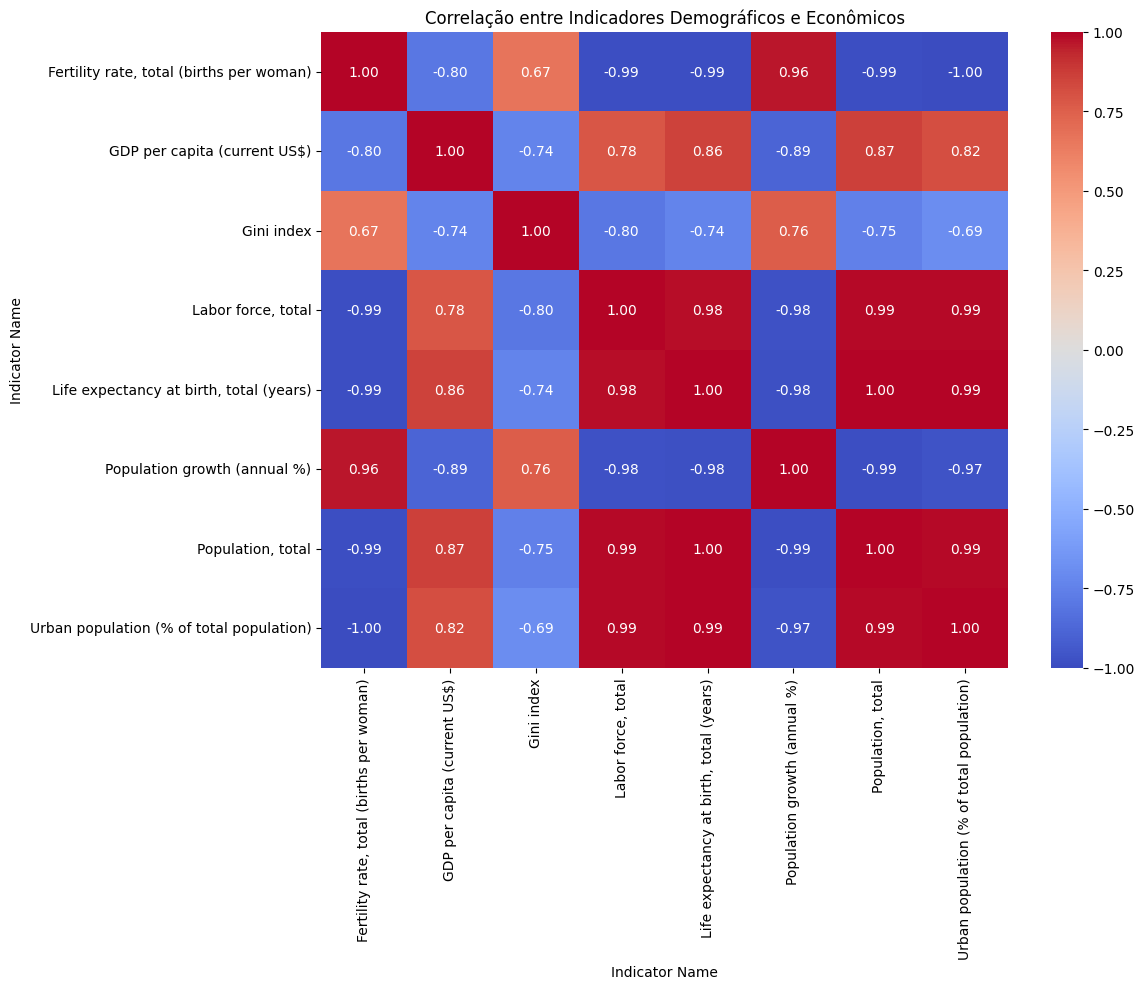

In [55]:
# Análise de correlação entre fatores demográficos e econômicos
indicadores_correlacao = [
    'Population, total',
    'Population growth (annual %)',
    'GDP per capita (current US$)',
    'Urban population (% of total population)',
    'Life expectancy at birth, total (years)',
    'Fertility rate, total (births per woman)',
    "Gini index",
    "Labor force, total"
]

# Filtrar apenas os indicadores selecionados
dados_corr = brasil[brasil['Indicator Name'].isin(indicadores_correlacao)]

# Pivotar para formato amplo
dados_corr_wide = dados_corr.pivot(index='Year', columns='Indicator Name', values='Value')

# Calcular correlação
matriz_corr = dados_corr_wide.corr()

# Plotar mapa de calor de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação entre Indicadores Demográficos e Econômicos')
plt.tight_layout()
plt.show()

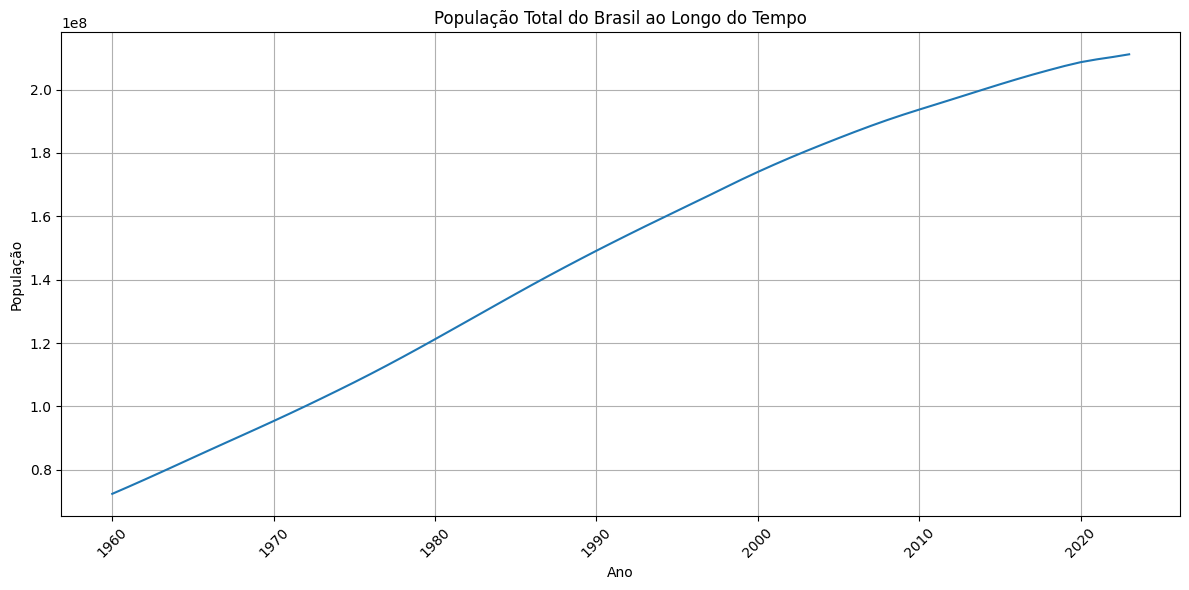

In [21]:
# Visualizar a tendência histórica da população total
plt.figure(figsize=(12, 6))
pop_brasil = brasil[brasil['Indicator Name'] == 'Population, total']
sns.lineplot(data=pop_brasil, x='Year', y='Value')
plt.title('População Total do Brasil ao Longo do Tempo')
plt.ylabel('População')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

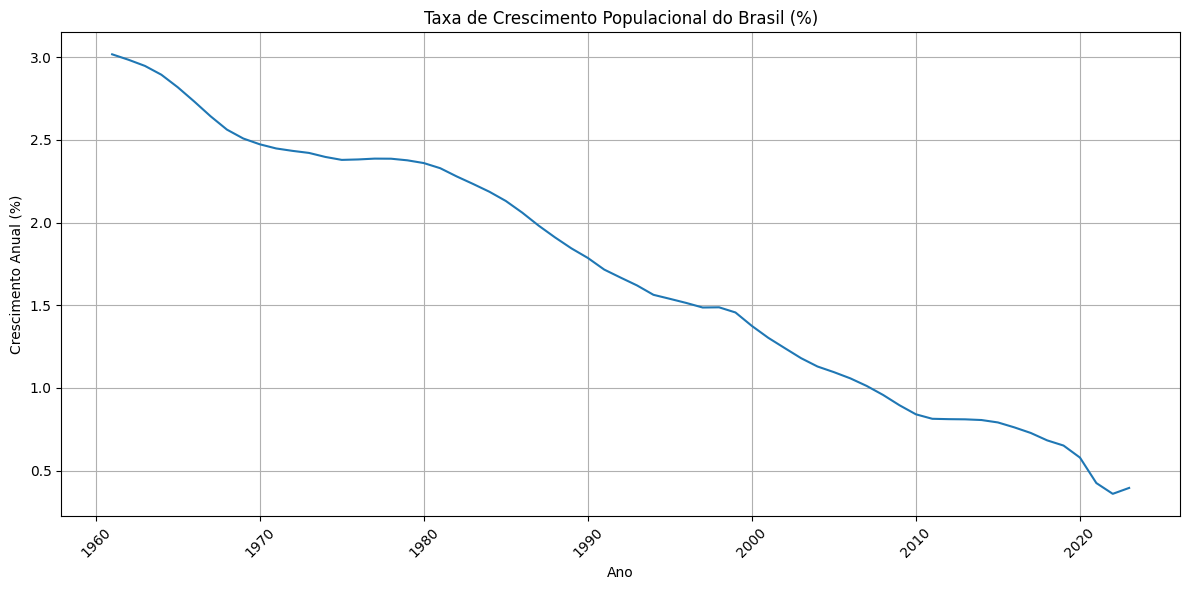

In [22]:
# Visualizar taxas de crescimento populacional
crescimento_pop = brasil[brasil['Indicator Name'] == 'Population growth (annual %)']
plt.figure(figsize=(12, 6))
sns.lineplot(data=crescimento_pop, x='Year', y='Value')
plt.title('Taxa de Crescimento Populacional do Brasil (%)')
plt.ylabel('Crescimento Anual (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [24]:
# Análise de fatores demográficos que afetam a população
fatores_demograficos = [
    'Fertility rate, total (births per woman)',
    'Mortality rate, infant (per 1.000 live births)',
    'Life expectancy at birth, total (years)',
    'Birth rate, crude (per 1.000 people)'
]

# Normalizando os dados para visualização conjunta
dados_demograficos = brasil[brasil['Indicator Name'].isin(fatores_demograficos)].copy()

# Pivot para ter cada indicador como coluna
dados_pivot = dados_demograficos.pivot(index='Year', columns='Indicator Name', values='Value')

# Normalização min-max para cada coluna
dados_norm = (dados_pivot - dados_pivot.min()) / (dados_pivot.max() - dados_pivot.min())


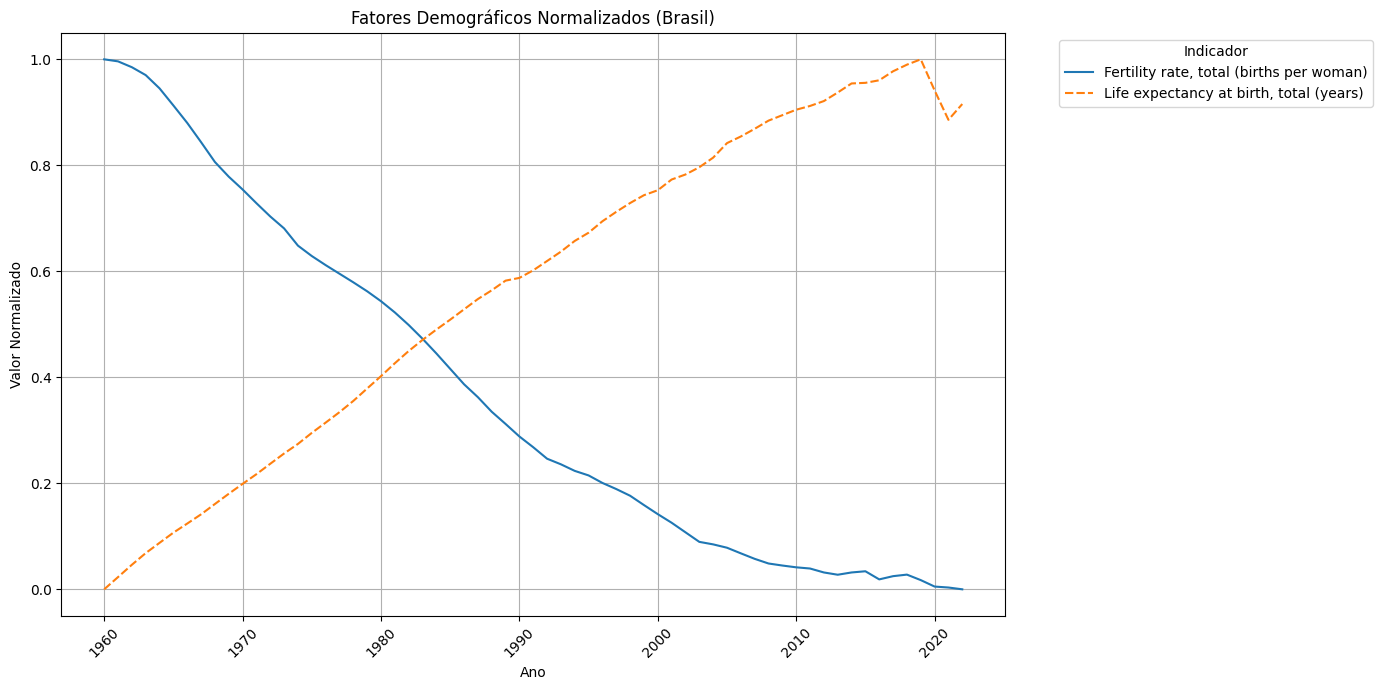

In [25]:
# Plotando dados normalizados
plt.figure(figsize=(14, 7))
sns.lineplot(data=dados_norm)
plt.title('Fatores Demográficos Normalizados (Brasil)')
plt.ylabel('Valor Normalizado')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Indicador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

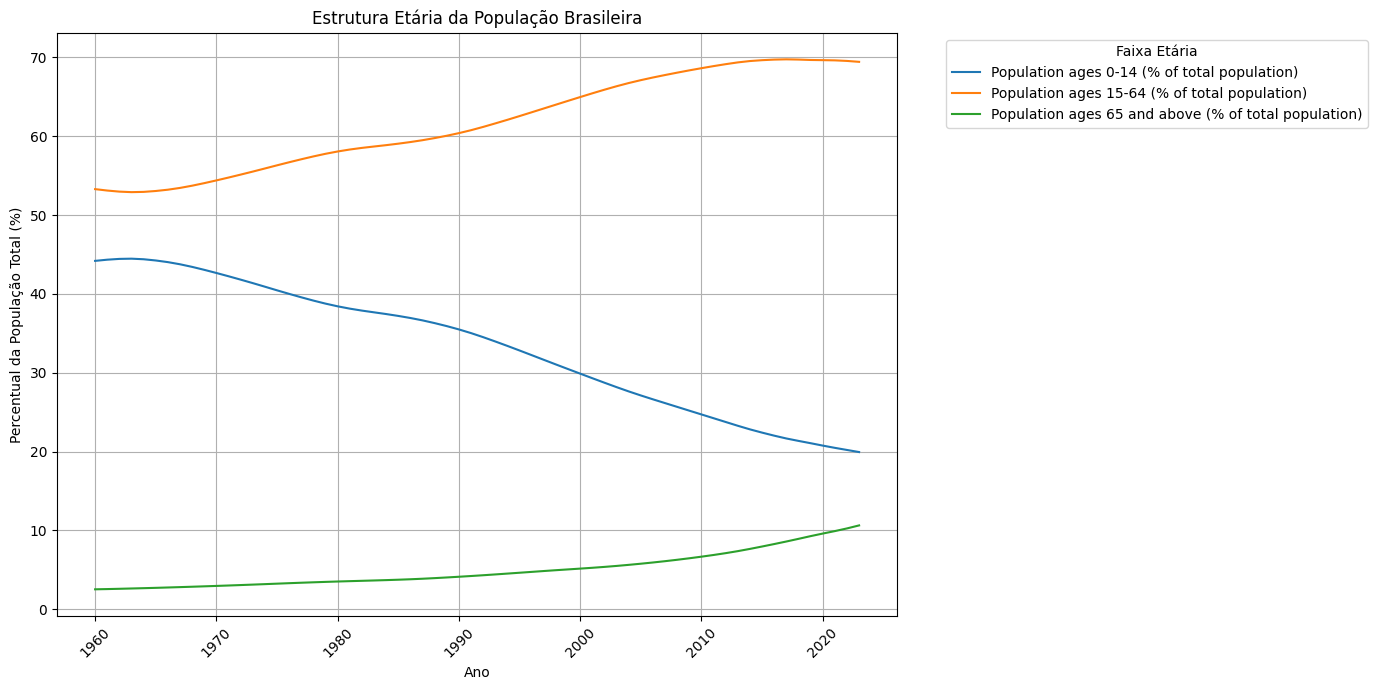

In [23]:
# Análise da estrutura etária ao longo do tempo
faixas_etarias = [
    'Population ages 0-14 (% of total population)',
    'Population ages 15-64 (% of total population)',
    'Population ages 65 and above (% of total population)'
]

estrutura_etaria = brasil[brasil['Indicator Name'].isin(faixas_etarias)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=estrutura_etaria, x='Year', y='Value', hue='Indicator Name')
plt.title('Estrutura Etária da População Brasileira')
plt.ylabel('Percentual da População Total (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Faixa Etária', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


In [ ]:
fertilidade = brasil[brasil['Indicator Name'] == 'Fertility rate, total (births per woman)'][['Year', 'Value']].rename(columns={'Value': 'Fertility Rate'})
populacao_total = brasil[brasil['Indicator Name'] == 'Population, total'][['Year', 'Value']].rename(columns={'Value': 'Population Total'})
urbanizacao = brasil[brasil['Indicator Name'] == 'Urban population (% of total population)'][['Year', 'Value']].rename(columns={'Value': 'Urbanization (%)'})


df_plot = populacao_total.merge(fertilidade, on='Year').merge(urbanizacao, on='Year')


fig = px.scatter(
    df_plot,
    x='Population Total',
    y='Fertility Rate',
    size='Urbanization (%)',  # Tamanho dos pontos baseado no percentual de urbanização
    color='Urbanization (%)',  # Cor dos pontos baseado no percentual de urbanização
    hover_data=['Year'],  # Mostrar o ano ao passar o mouse
    title='Relação entre Fertilidade, População Total e Urbanização (Brasil)',
    labels={'Fertility Rate': 'Taxa de Fertilidade', 'Population Total': 'População Total', 'Urbanization (%)': 'Urbanização (%)'}
)

fig.show()

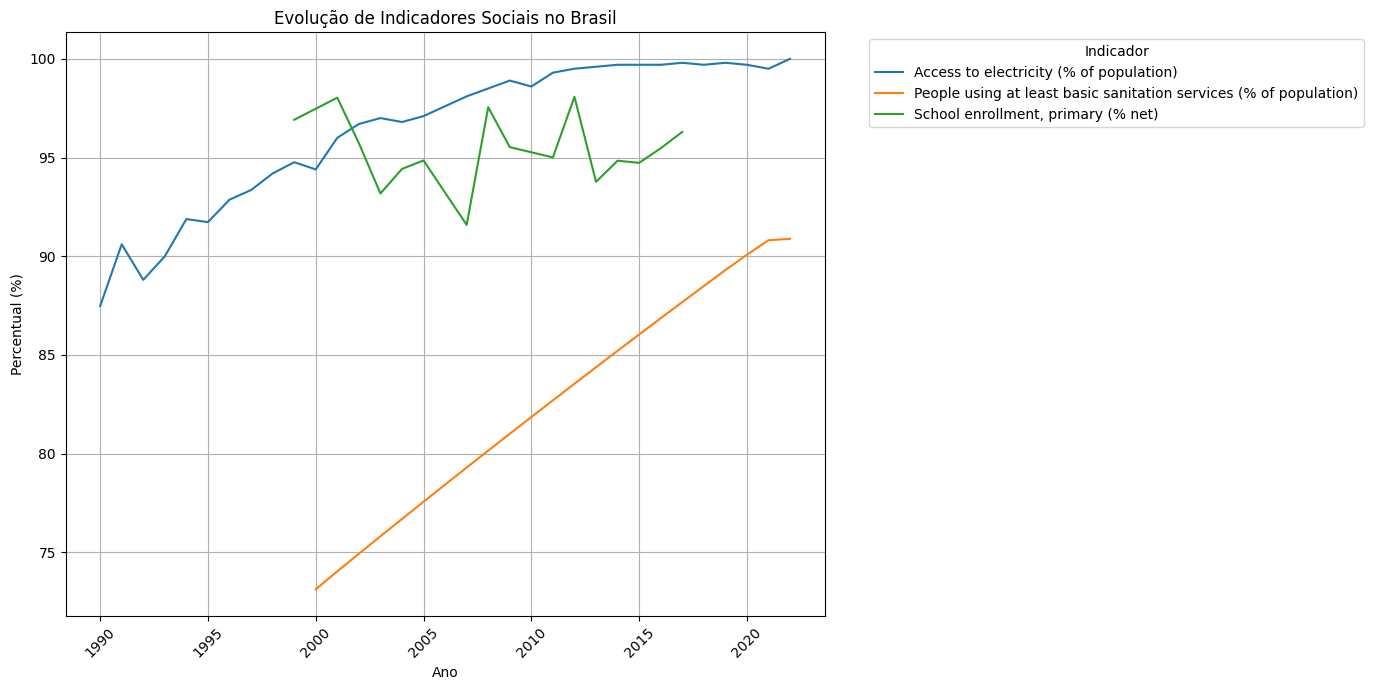

In [29]:
# Análise da evolução de indicadores sociais que podem impactar a demografia
indicadores_sociais = [
    'School enrollment, primary (% net)',
    'Internet usage (% of population)',
    'Access to electricity (% of population)',
    'People using at least basic sanitation services (% of population)'
]

dados_sociais = brasil[brasil['Indicator Name'].isin(indicadores_sociais)]

plt.figure(figsize=(14, 7))
sns.lineplot(data=dados_sociais, x='Year', y='Value', hue='Indicator Name')
plt.title('Evolução de Indicadores Sociais no Brasil')
plt.ylabel('Percentual (%)')
plt.xlabel('Ano')
plt.grid(True)
plt.xticks(rotation=45)
plt.legend(title='Indicador', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

#### Urbanizão x economia

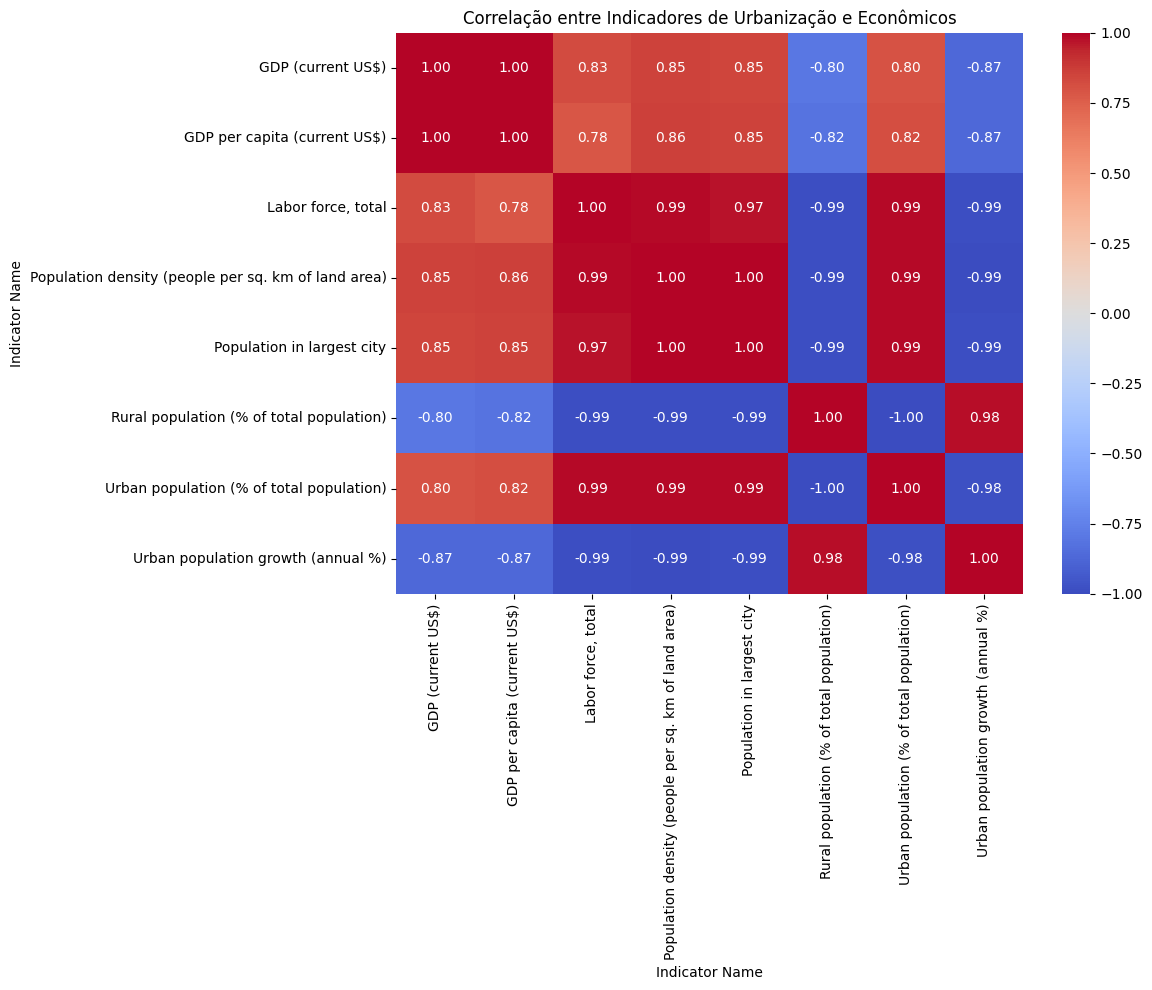

In [62]:

# Análise de correlação entre fatores de urbanização e econômicos
indicadores_correlacao = [
        ## Econômicos:
    "GDP per capita (current US$)",
    "Unemployment, total (% of total labor force)",
    "GDP (current US$)",
    "Labor force, total",

    ## Urbanização:
    "Urban population (% of total population)",
    "Urban population growth (annual %)",
    "Population in largest city",
    "Urban land area (% of total land area)",
    "Population density (people per sq. km of land area)",
    "Rural population (% of total population)"
]

# Filtrar apenas os indicadores selecionados
dados_corr = brasil[brasil['Indicator Name'].isin(indicadores_correlacao)]

# Pivotar para formato amplo
dados_corr_wide = dados_corr.pivot(index='Year', columns='Indicator Name', values='Value')

# Calcular correlação
matriz_corr = dados_corr_wide.corr()

# Plotar mapa de calor de correlação
plt.figure(figsize=(12, 10))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlação entre Indicadores de Urbanização e Econômicos')
plt.tight_layout()
plt.show()

## comparação

In [30]:
# Lista de países para comparação
paises_comparacao = ["Brazil", "Russia", "India", "China", "South Africa",  # BRICS
                     "Argentina", "Mexico", "Colombia", "Chile"]  # América Latina

# Filtrar dados apenas para esses países
dados_comparacao = dados_long[dados_long["Country Name"].isin(paises_comparacao)]
dados_comparacao = dados_comparacao[dados_comparacao["Indicator Name"].isin(indicadores_interesse)]

# Criar subconjuntos para cada país
sub_dfs_paises_comparacao = {pais: grupo for pais, grupo in dados_comparacao.groupby("Country Name")}

# Criar dataframes pivotados para cada país
dfs_wide_por_pais = {}
for pais in sub_dfs_paises_comparacao:
    df_temp = sub_dfs_paises_comparacao[pais][["Year", "Indicator Name", "Value"]].copy()
    dfs_wide_por_pais[pais] = df_temp.pivot(
        index="Year",
        columns="Indicator Name",
        values="Value"
    )
    dfs_wide_por_pais[pais].sort_index(inplace=True)

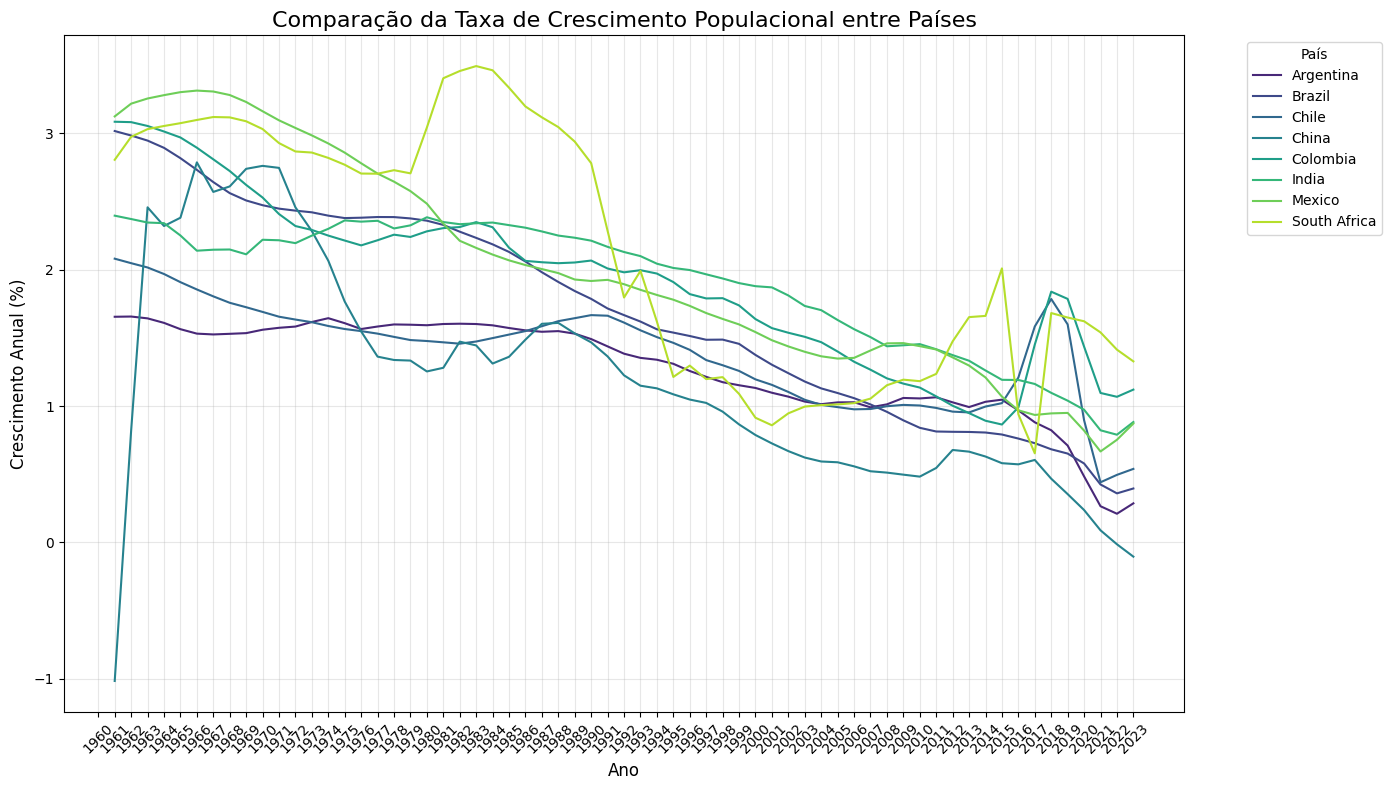

In [31]:
# Extrair dados de crescimento populacional para cada país
dados_crescimento = dados_comparacao[dados_comparacao['Indicator Name'] == 'Population growth (annual %)']

plt.figure(figsize=(14, 8))
sns.lineplot(data=dados_crescimento, x='Year', y='Value', hue='Country Name', palette='viridis')
plt.title('Comparação da Taxa de Crescimento Populacional entre Países', fontsize=16)
plt.ylabel('Crescimento Anual (%)', fontsize=12)
plt.xlabel('Ano', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.legend(title='País', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [33]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Criar um painel com múltiplos gráficos
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        "População Total", 
        "Taxa de Crescimento Populacional",
        "Urbanização vs. Expectativa de Vida", 
        "PIB per Capita vs. Taxa de Fertilidade"
    ),
    specs=[[{"type": "scatter"}, {"type": "scatter"}],
           [{"type": "scatter"}, {"type": "scatter"}]]
)

# Gráfico 1: População Total de países selecionados
for pais in ["Brazil", "Argentina", "Mexico", "Colombia"]:
    df_pop = dados_comparacao[(dados_comparacao['Country Name'] == pais) & 
                           (dados_comparacao['Indicator Name'] == 'Population, total')]
    fig.add_trace(
        go.Scatter(x=df_pop['Year'], y=df_pop['Value'], mode='lines', name=f"{pais} - População"),
        row=1, col=1
    )

# Gráfico 2: Taxa de Crescimento Populacional
for pais in ["Brazil", "Argentina", "Mexico", "Colombia"]:
    df_cresc = dados_comparacao[(dados_comparacao['Country Name'] == pais) & 
                             (dados_comparacao['Indicator Name'] == 'Population growth (annual %)')]
    fig.add_trace(
        go.Scatter(x=df_cresc['Year'], y=df_cresc['Value'], mode='lines', name=f"{pais} - Crescimento"),
        row=1, col=2
    )

# Gráfico 3: Urbanização vs. Expectativa de Vida (Brasil)
anos_selecionados = [1990, 1995, 2000, 2005, 2010, 2015, 2020]
df_urban = dados_comparacao[(dados_comparacao['Country Name'] == 'Brazil') & 
                         (dados_comparacao['Indicator Name'] == 'Urban population (% of total population)')]
df_life = dados_comparacao[(dados_comparacao['Country Name'] == 'Brazil') & 
                        (dados_comparacao['Indicator Name'] == 'Life expectancy at birth, total (years)')]

df_urban_life = pd.merge(df_urban, df_life, on=['Year', 'Country Name'], 
                         suffixes=('_urban', '_life'))
df_urban_life = df_urban_life[df_urban_life['Year'].isin(anos_selecionados)]

fig.add_trace(
    go.Scatter(
        x=df_urban_life['Value_urban'],
        y=df_urban_life['Value_life'],
        mode='markers+text',
        text=df_urban_life['Year'],
        textposition="top center",
        marker=dict(size=10),
        name="Brasil - Urbanização vs. Expectativa"
    ),
    row=2, col=1
)

# Gráfico 4: PIB per Capita vs. Taxa de Fertilidade (comparação entre países)
for pais in ["Brazil", "Argentina", "Mexico", "Colombia"]:
    df_gdp = dados_comparacao[(dados_comparacao['Country Name'] == pais) & 
                           (dados_comparacao['Indicator Name'] == 'GDP per capita (current US$)')]
    df_fert = dados_comparacao[(dados_comparacao['Country Name'] == pais) & 
                            (dados_comparacao['Indicator Name'] == 'Fertility rate, total (births per woman)')]
    
    df_gdp_fert = pd.merge(df_gdp, df_fert, on=['Year', 'Country Name'], 
                          suffixes=('_gdp', '_fert'))
    df_gdp_fert = df_gdp_fert[df_gdp_fert['Year'].isin(anos_selecionados)]
    
    fig.add_trace(
        go.Scatter(
            x=df_gdp_fert['Value_gdp'],
            y=df_gdp_fert['Value_fert'],
            mode='markers+lines',
            marker=dict(size=8),
            name=f"{pais} - PIB vs. Fertilidade"
        ),
        row=2, col=2
    )

# Atualizar layout
fig.update_layout(height=800, width=1200, title_text="Painel de Indicadores Demográficos", 
                 legend=dict(orientation="h", yanchor="bottom", y=-0.2))
fig.update_xaxes(title_text="População", row=1, col=1)
fig.update_yaxes(title_text="Valor", row=1, col=1)
fig.update_xaxes(title_text="Ano", row=1, col=2)
fig.update_yaxes(title_text="Crescimento (%)", row=1, col=2)
fig.update_xaxes(title_text="Urbanização (%)", row=2, col=1)
fig.update_yaxes(title_text="Expectativa de Vida (anos)", row=2, col=1)
fig.update_xaxes(title_text="PIB per Capita (US$)", row=2, col=2)
fig.update_yaxes(title_text="Taxa de Fertilidade", row=2, col=2)

fig.show()

In [34]:
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Preparar dados para regressão - Brasil
df_reg = df_brasil_wide.copy().reset_index()

# Selecionar variáveis potencialmente relevantes para a regressão
variaveis_modelo = [
    'GDP per capita (current US$)',
    'Urban population (% of total population)',
    'Life expectancy at birth, total (years)',
    'Fertility rate, total (births per woman)',
    'Literacy rate, adult total (% of people ages 15 and above)',
    'Internet usage (% of population)'
]

# Remover dados ausentes
variaveis_modelo_presentes = [var for var in variaveis_modelo if var in df_reg.columns]
df_reg_limpo = df_reg.dropna(subset=['Population growth (annual %)'] + variaveis_modelo_presentes)

# Fórmula para regressão
formula = 'Population growth (annual %) ~ ' + ' + '.join([f'`{var}`' for var in variaveis_modelo_presentes])

# Executar regressão
modelo = ols(formula, data=df_reg_limpo).fit()
print(modelo.summary())

# Visualizar a importância das variáveis
plt.figure(figsize=(12, 8))
coefs = modelo.params[1:].sort_values(ascending=False)
colors = ['green' if x > 0 else 'red' for x in coefs]
sns.barplot(x=coefs.values, y=coefs.index, palette=colors)
plt.title('Coeficientes de Regressão - Fatores que Influenciam o Crescimento Populacional', fontsize=16)
plt.xlabel('Magnitude do Coeficiente', fontsize=12)
plt.ylabel('Variável', fontsize=12)
plt.axvline(x=0, color='black', linestyle='-')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# Verificar a relação entre valores previstos e reais
plt.figure(figsize=(10, 6))
plt.scatter(modelo.fittedvalues, df_reg_limpo['Population growth (annual %)'], alpha=0.6)
plt.plot([df_reg_limpo['Population growth (annual %)'].min(), df_reg_limpo['Population growth (annual %)'].max()], 
         [df_reg_limpo['Population growth (annual %)'].min(), df_reg_limpo['Population growth (annual %)'].max()], 
         'r--')
plt.xlabel('Valores Previstos', fontsize=12)
plt.ylabel('Valores Reais', fontsize=12)
plt.title('Valores Previstos vs. Reais - Crescimento Populacional', fontsize=16)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

SyntaxError: invalid syntax (<unknown>, line 1)

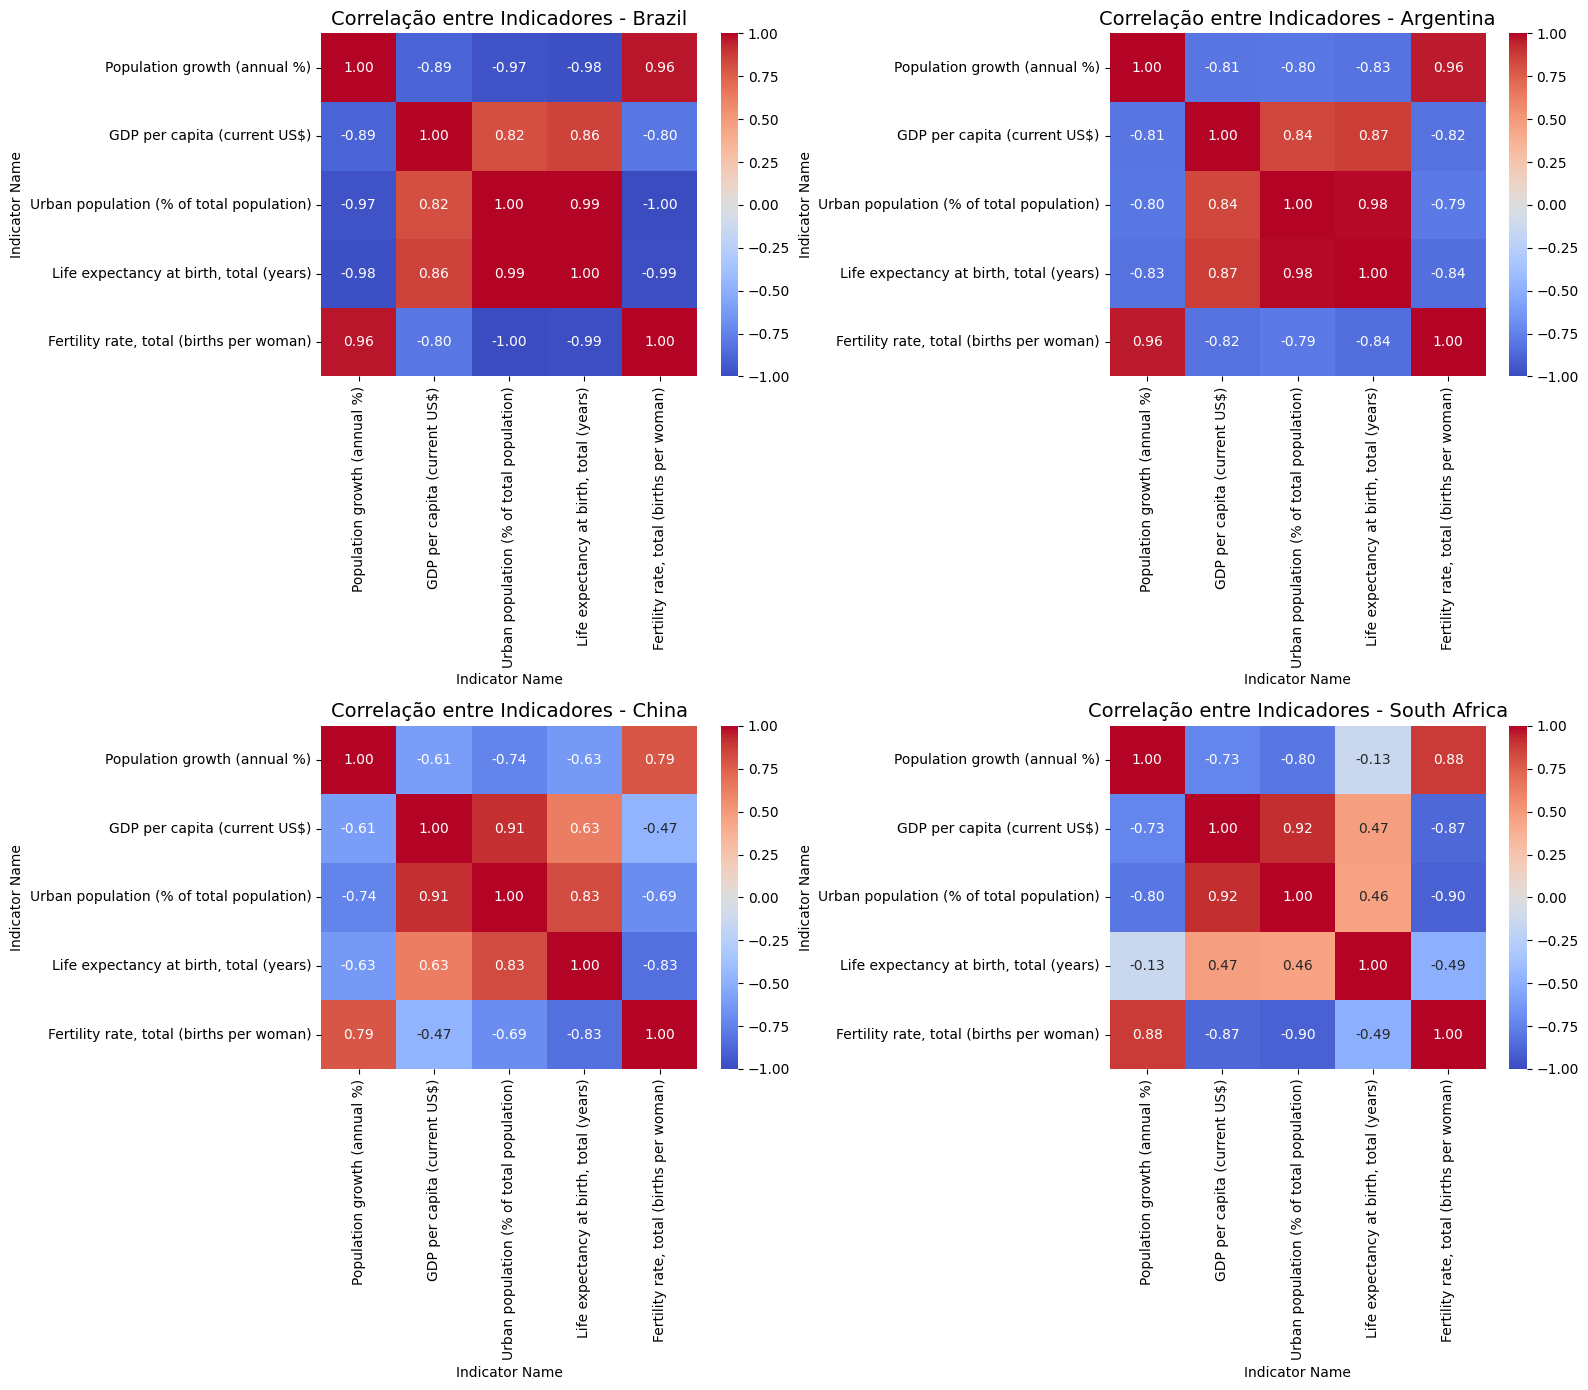

In [ ]:
# Selecionar indicadores importantes para análise de correlação
indicadores_correl = [
    'Population growth (annual %)',
    'GDP per capita (current US$)',
    'Urban population (% of total population)',
    'Life expectancy at birth, total (years)',
    'Fertility rate, total (births per woman)'
]

# Criar gráficos de correlação para cada país
paises_analise = ["Brazil", "Argentina", "China", "South Africa"]
fig, axs = plt.subplots(2, 2, figsize=(16, 14))
axs = axs.flatten()

for i, pais in enumerate(paises_analise):
    # Verificar se temos dados suficientes
    if pais in dfs_wide_por_pais:
        df_pais = dfs_wide_por_pais[pais]
        # Selecionar apenas indicadores disponíveis
        ind_disponiveis = [ind for ind in indicadores_correl if ind in df_pais.columns]
        
        if len(ind_disponiveis) >= 2:  # Precisamos de pelo menos 2 indicadores para correlação
            matriz_corr = df_pais[ind_disponiveis].corr()
            
            # Plotar heatmap
            sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                       fmt='.2f', ax=axs[i])
            axs[i].set_title(f'Correlação entre Indicadores - {pais}', fontsize=14)
        else:
            axs[i].text(0.5, 0.5, f"Dados insuficientes para {pais}", 
                       horizontalalignment='center', verticalalignment='center')
    else:
        axs[i].text(0.5, 0.5, f"Sem dados disponíveis para {pais}", 
                   horizontalalignment='center', verticalalignment='center')

plt.tight_layout()
plt.show()